Independent Algorithms:

Yevgen: Gradient Boost / XGBoost

Gabrielle: Neural Network

Arthur: Random Forest

Eden: Logistic Regression

JJ: KNN

# Project Introduction

### What is the goal of your project?
The goal of our project is to build predictive models that identify companies likely to go bankrupt based on their financial statement data. Using machine learning, we aim to classify firms as either "alive" or "bankrupt," enabling better credit risk assessment and early warning for financial distress. Each group member contributes a different algorithm to compare interpretability, accuracy, and performance under class imbalance.

### What is the data that you are using? What is the original data source if known?
We use a dataset from Kaggle titled “American Bankruptcy Prediction”, which contains real-world financial statement data for thousands of U.S. companies. It includes raw accounting metrics over multiple years. While Kaggle is the hosting platform, the dataset appears to be derived from larger institutional sources such as WRDS or Compustat.

### What does an instance in your data represent? How many instances are there?
Each row represents a **single company in a specific year**, providing a snapshot of that firm’s financial condition.  
There are **78,682 instances** total.

### What is the target variable you are trying to predict?
The target variable is `status_label`, a binary indicator:
- `alive` (non-bankrupt)
- `failed` (bankrupt)

This is converted into a numeric label for modeling, where:
- `0` = alive  
- `1` = bankrupt

### What are the features used to predict it? Give a few examples.
The original dataset includes 18 raw financial variables (`X1` to `X18`). To improve interpretability and comparability across firms, we computed financial ratio features as a shared preprocessing step. These include:

- `profit_margin` = X3 / X1
- `debt_ratio` = X6 / X5
- `current_ratio` = X5 / X7
- `asset_turnover` = X1 / X5
- `roe` = X4 / X5
- `ebit_margin` = X12 / X1

These ratios normalize firm size and capture key financial signals (profitability, liquidity, leverage).

### Provide any additional relevant information about your data if known
- The dataset spans multiple years, with a `year` column for time tracking.
- It covers U.S.-based firms across many sectors.
- The class distribution is highly imbalanced: ~93% alive vs. ~7% bankrupt.
- This imbalance makes the prediction task more realistic and challenging.

# **Project Design and Innovation**

Our project addresses the problem of corporate bankruptcy prediction using financial statement data, a critical area in financial risk management. The primary innovation in our approach lies in transforming raw accounting variables into financial ratios. This design decision normalizes firm size and enhances interpretability, allowing us to develop scalable and firm-agnostic predictive models.

We implemented a diverse set of machine learning algorithms—each contributed by a different group member—to compare model performance and robustness. These included:
- **Logistic Regression** (Eden)– provided a transparent baseline model with strong recall through class balancing
- **Random Forest** (Arthur)-leveraged ensemble averaging for robust non-linear performance
- **Gradient Boosting / XGBoost** (Yevgen)-optimized classification through iterative boosting and fine-tuning
- **Neural Network** (Gabrielle)-captured complex patterns in high-dimensional space via deep learning
- **KNN** (JJ)-contributed a simple but interpretable distance-based learner

This multi-model framework enables cross-validation and benchmarking of performance under various assumptions, which is aligned with best practices in applied financial machine learning.

We also tackled the significant class imbalance in the data (with bankrupt firms making up less than 7% of observations) through techniques such as:
- using `class_weight='balanced'` in linear models,
- exploring oversampling methods,
- and emphasizing recall over precision for the minority class.

In designing the project, we prioritized reproducibility and modularity. All code is organized into clean, reusable blocks, and we used consistent preprocessing across all models. This structure allows easy comparison and integration of additional models in the future.

Lastly, our project reflects an applied, empirical approach encouraged in class: leveraging real financial data, validating our methods through quantitative metrics, and interpreting results through a financial lens. We believe this project demonstrates a thoughtful balance between domain relevance, algorithmic rigor, and practical implementation.


# **Data Processing and Feature Engineering**

# Company Specific Features

The datasource for this project is a kaggle dataset: https://www.kaggle.com/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset.

The dataset was created using the accounting data from NYSE and NASDAQ listed companies between the years 1999 - 2018. This dataset is being used to predict if a company will go bankrupt. Each entry is composed of a 'status_label' that determines where a company is still alive or has gone bankrupt - this is the target variable that we will try to predict with our models. Each entry also contains a 'year' feature, a company name feature, and accounting features pulled from the financial statements of the company in a given year. These accounting features include current assets, COGS, EBITDA, Net Income, Inventory, etc. In total there are 18 of these financial features for each year/company entry.

In order to work with our dataset and compare companies of different scales, we transformed our features into common financial ratios that we could train our model on. We dropped the initial features (non-ratios) as they would make it difficult to compare companies of varying sizes.

Liquidity ratios: Current Ratio, Quick Ratio, Cash Ratio

Profitability Ratios: Net Profit Margin, EBIT Margin, Gross Margin, Return on Assets, Return on Sales, Depreciation & Amortization to Sales

Leverage Ratios: Debt to Assets, Debt to EBITDA, Long-term Debt to Capitalization

Efficiency Ratios: Inventory Turnover, Receivables Turnover, Asset Turnover, Operating Expense Ratio, Inventory to Assets

Capital Market Multiples: Capitalization to Sales, Capitalization to Earnings, EV/EBITDA

In [ ]:
! pip install kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
! cp /content/drive/MyDrive/cfrm421/kaggle.json ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets download -d utkarshx27/american-companies-bankruptcy-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset
License(s): CC0-1.0
american-companies-bankruptcy-prediction-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
! unzip american-companies-bankruptcy-prediction-dataset.zip

Archive:  american-companies-bankruptcy-prediction-dataset.zip
replace american_bankruptcy.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import numpy as np
import pandas as pd
import datetime as dt
from pandas_datareader import data as web

df = pd.read_csv('american_bankruptcy.csv')
# df = pd.read_csv('https://raw.githubusercontent.com/sowide/bankruptcy_dataset/refs/heads/main/american_bankruptcy_dataset.csv')

### Company Features

In [ ]:
df.rename(columns={
    'X1': 'current_assets',
    'X2': 'cogs',
    'X3': 'depreciation_amortization',
    'X4': 'ebitda',
    'X5': 'inventory',
    'X6': 'net_income',
    'X7': 'total_receivables',
    'X8': 'market_value',
    'X9': 'net_sales',
    'X10': 'total_assets',
    'X11': 'long_term_debt',
    'X12': 'ebit',
    'X13': 'gross_profit',
    'X14': 'current_liabilities',
    'X15': 'retained_earnings',
    'X16': 'total_revenue',
    'X17': 'total_liabilities',
    'X18': 'total_operating_expense',
}, inplace=True)

In [ ]:
df.head()

,company_name,status_label,year,current_assets,cogs,depreciation_amortization,ebitda,inventory,net_income,total_receivables,...,net_sales,total_assets,long_term_debt,ebit,gross_profit,current_liabilities,retained_earnings,total_revenue,total_liabilities,total_operating_expense
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [ ]:
# the lowest non-zero entry for inventory is 0.001. since it's used a the denominator in ratios
# we want to avoid NaNs. fill zero values with 0.001
for c in ['inventory', 'total_receivables', 'net_income', 'ebitda']:
  df.loc[df[c] == 0, c] = 0.001
# Liquidity Ratios
df['current_ratio'] = df['current_assets'] / df['current_liabilities']
df['quick_ratio'] = (df['current_assets'] - df['inventory']) / df['current_liabilities']
df['cash_ratio'] = (df['current_assets'] - df['inventory'] - df['total_receivables']) / df['current_liabilities']
# Profitability ratios
df['net_profit_margin'] = df['net_income'] / df['net_sales']
df['ebit_margin'] = df['ebit'] / df['net_sales']
df['gross_margin'] = df['gross_profit'] / df['net_sales']
df['return_on_assets'] = df['net_income'] / df['total_assets']
df['return_on_sales'] = df['ebit'] / df['total_revenue']
df['da_to_sales'] = df['depreciation_amortization'] / df['net_sales']
# Leverage ratios
df['debt_to_assets'] = df['total_liabilities'] / df['total_assets']
df['debt_to_ebitda'] = df['total_liabilities'] / df['ebitda']
df['long_term_debt_to_capitalization'] = df['long_term_debt'] / (df['long_term_debt'] + (df['total_assets'] - df['total_liabilities']))
# Efficiency ratios
df['inventory_turnover'] = df['cogs'] / df['inventory']
df['receivables_turnover'] = df['net_sales'] / df['total_receivables']
df['asset_turnover'] = df['net_sales'] / df['total_assets']
df['operating_expense_ratio'] = df['total_operating_expense'] / df['total_revenue']
df['inventory_assets'] = df['inventory'] / df['total_assets']
# Cap multiples
df['cap_to_sales'] = df['market_value'] / df['net_sales']
df['cap_to_earnings'] = df['market_value'] / df['net_income']
df['ev_ebitda_approx']  = (df['market_value'] + df['long_term_debt']) / df['ebitda']

In [ ]:
df.head()

,company_name,status_label,year,current_assets,cogs,depreciation_amortization,ebitda,inventory,net_income,total_receivables,...,debt_to_ebitda,long_term_debt_to_capitalization,inventory_turnover,receivables_turnover,asset_turnover,operating_expense_ratio,inventory_assets,cap_to_sales,cap_to_earnings,ev_ebitda_approx
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,4.509474,0.347039,2.479352,7.980903,1.382369,0.913084,0.453467,0.363897,10.600685,6.213554
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,5.618438,0.345996,2.226554,7.589876,1.245637,0.926375,0.456776,0.431359,20.350656,8.655134
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,14.700776,0.412360,1.837052,8.238585,0.899355,0.957404,0.403532,0.570817,-6.185935,21.402279
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,12.738104,0.358228,1.910903,9.142321,0.883074,0.949294,0.378599,0.236386,-11.549517,10.017483
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,8.582847,0.451832,2.116532,6.229235,0.919167,0.927156,0.348580,0.473814,88.158419,11.740606


In [ ]:
df_ratios = df.drop([
    'current_assets',
    'cogs',
    'depreciation_amortization',
    'ebitda',
    'inventory',
    'net_income',
    'total_receivables',
    'market_value',
    'net_sales',
    'total_assets',
    'long_term_debt',
    'ebit',
    'gross_profit',
    'current_liabilities',
    'retained_earnings',
    'total_revenue',
    'total_liabilities',
    'total_operating_expense'
], axis=1)

In [ ]:
print(df_ratios.shape)
df_ratios.head()

(78682, 23)


,company_name,status_label,year,current_ratio,quick_ratio,cash_ratio,net_profit_margin,ebit_margin,gross_margin,return_on_assets,...,debt_to_ebitda,long_term_debt_to_capitalization,inventory_turnover,receivables_turnover,asset_turnover,operating_expense_ratio,inventory_assets,cap_to_sales,cap_to_earnings,ev_ebitda_approx
0,C_1,alive,1999,3.120983,1.069792,0.286303,0.034328,0.068980,0.186683,0.047454,...,4.509474,0.347039,2.479352,7.980903,1.382369,0.913084,0.453467,0.363897,10.600685,6.213554
1,C_1,alive,2000,3.874697,1.317995,0.399380,0.021196,0.052376,0.183521,0.026403,...,5.618438,0.345996,2.226554,7.589876,1.245637,0.926375,0.456776,0.431359,20.350656,8.655134
2,C_1,alive,2001,2.902063,0.997368,0.482109,-0.092277,0.007376,0.175732,-0.082989,...,14.700776,0.412360,1.837052,8.238585,0.899355,0.957404,0.403532,0.570817,-6.185935,21.402279
3,C_1,alive,2002,1.947253,0.670308,0.344522,-0.020467,0.005893,0.180741,-0.018074,...,12.738104,0.358228,1.910903,9.142321,0.883074,0.949294,0.378599,0.236386,-11.549517,10.017483
4,C_1,alive,2003,3.292707,1.409093,0.611743,0.005375,0.031921,0.197338,0.004940,...,8.582847,0.451832,2.116532,6.229235,0.919167,0.927156,0.348580,0.473814,88.158419,11.740606


In [ ]:
# assert there are no problematic values - nan, inf, etc
assert not (df_ratios.isna()).any().any()
assert not (df_ratios == np.inf).any().any()
assert not (df_ratios == -np.inf).any().any()

# Macro-Economic Features


Macroeconomic indicators are incorporated alongside firm-level ratios because corporate distress is rarely driven by idiosyncratic balance-sheet weakness alone; broad shifts in growth, inflation, credit spreads, rates and market volatility set the backdrop against which a company either survives or fails. We source those indicators directly from the Federal Reserve Economic Data (FRED) repository, a well-documented, freely accessible feed maintained by the St. Louis Fed. FRED is widely regarded as the “gold standard” for U.S. macro time series: each series carries a clear metadata sheet (frequency, units, seasonal-adjustment method, revision policy). The selected set spans real activity (GDP, industrial production), labour conditions (unemployment, initial claims), price dynamics (headline CPI, WTI oil), money and credit aggregates (M2, BBB OAS spread, Baa yield), interest-rate term structure (2- and 10-year Treasuries, mortgage rates, yield-curve slope), and forward-looking stress gauges (VIX, STLFSI). Together they proxy the macro channels most often cited in bankruptcy models—demand collapse, funding cost spikes and systemic stress.

After downloading monthly or daily rows with pandas-datareader, we resample everything to 31-December of each year so macro data align exactly with the firm fiscal-year features. This annualisation ensures no intra-year look-ahead bias and removes high-frequency noise that is immaterial to a twelve-month default horizon. We then apply simple but effective techniques to transform the data.
1. Convert raw dollar or index levels into year-over-year percentage growth for flow-like series (GDP, CPI, IP, oil, claims, M2) to make them scale-neutral and stationary.
2. Build economically interpretable transformations such as the 10s-2s yield-curve slope and one-year deltas in key rates or spreads to capture directional shocks that often precede credit events
These steps represent reasonable preprocessing—they keep the tree algorithms from over-reacting to level shifts in non-stationary variables while preserving the signal embedded in growth or spread changes.

Each included feature reflects an economic narrative (e.g., a steepening yield curve tightens funding for BBB issuers, rising VIX telegraphs market strain) and, by design, the resulting variables are on comparable percentage or basis-point scales that GB and XGB can partition efficiently. The deliberate choice to include only first lags (YoY growth, Δ1-year rates) keeps the feature space manageable Overall, this macro block complements firm ratios with systemic context, is built from publicly reliable data, cleansed through transparent resampling and differencing, and engineered into stationary, economically interpretable inputs that enhance the model’s ability to flag impending bankruptcies during adverse macro regimes.

In [ ]:
import datetime as dt
import pandas_datareader.data as web
import pandas as pd

In [ ]:
company_features = df_ratios.copy()
fred_map = {
    # Real Gross Domestic Product
    "GDPC1": "real_gdp",
    # Industrial Production Index
    "INDPRO": "industrial_production",
    # Civilian Unemployment Rate
    "UNRATE": "unemployment_rate",
    # Initial Jobless Claims
    "ICSA": "initial_jobless_claims",
    # CPI-U: All Items, 1982-84 = 100
    "CPIAUCSL": "cpi_all_items",
    # West Texas Intermediate (WTI) crude oil price, dollars per barrel
    "DCOILWTICO": "wti_crude_oil_price",
    # 10-Year Treasury Constant-Maturity Yield
    "DGS10": "treasury_10y_yield",
    # 2-Year Treasury Constant-Maturity Yield
    "DGS2": "treasury_2y_yield",
    # Moody’s Seasoned Baa Corporate Bond Yield
    "DBAA": "baa_corporate_yield",
    # ICE BofA U.S. Corporate BBB Option-Adjusted Spread
    "BAMLC0A4CBBB": "bbb_oas_spread",
    # CBOE Volatility Index (VIX)
    "VIXCLS": "vix_index",
    # M2 Money Stock, billions of dollars
    "M2SL": "m2_money_stock",
    # St. Louis Fed Financial Stress Index
    "STLFSI2": "st_louis_fsi",
    # 30-Year Fixed-Rate Mortgage Average in the United States
    "MORTGAGE30US": "mortgage_rate_30y",
}

fred_series = list(fred_map.keys())
# get an extra year for YoY calculations
start_date = dt.date(company_features['year'].min()-1, 1, 1)
end_date = dt.date(company_features['year'].max(), 12, 31)
raw = web.DataReader(fred_series, "fred", start_date, end_date)    # monthly & daily rows mixed
annual_q4  = raw.resample("QE-DEC").last().resample("YE-DEC").last().rename(columns=fred_map)

In [ ]:
def macro_feature_engineering(raw_annual: pd.DataFrame) -> pd.DataFrame:
    """
    Takes a wide DataFrame with year-end macro levels and returns a set
    of stationary / scale-neutral features suitable for tree models.

    Assumes the columns are named as in `fred_map` and index is datetime
    at 31-Dec of each year.
    """
    df = raw_annual.copy()
    orig_cols = df.columns

    # --- growth rates ----------------------------------------------------
    pct_cols = [
        "real_gdp", "industrial_production", "cpi_all_items",
        "wti_crude_oil_price", "m2_money_stock",
        "initial_jobless_claims",
    ]
    for c in pct_cols:
        df[f"{c}_yoy_pct"] = df[c].pct_change()

    # --- rate & spread levels -------------------------------------------
    df["yield_curve_10s2s"] = df["treasury_10y_yield"] - df["treasury_2y_yield"]

    # Δ 1-year changes in key rates / spreads
    delta_cols = [
        "treasury_10y_yield", "treasury_2y_yield",
        "baa_corporate_yield", "bbb_oas_spread", "mortgage_rate_30y",
        "unemployment_rate", "st_louis_fsi", "vix_index"
    ]
    for c in delta_cols:
        df[f"{c}_chg"] = df[c].diff()

    # drop the first year (no YoY)
    df = df.iloc[1:]
    df = df.drop(columns=orig_cols)

    return df

In [ ]:
macro_features = macro_feature_engineering(annual_q4)
macro_features.index = macro_features.index.year
macro_features.index.name = 'year'
macro_features = macro_features.reset_index()
assert not macro_features.isnull().any().any()
assert not (macro_features == np.inf).any().any()
assert not (macro_features == -np.inf).any().any()

In [ ]:
macro_features.head()

,year,real_gdp_yoy_pct,industrial_production_yoy_pct,cpi_all_items_yoy_pct,wti_crude_oil_price_yoy_pct,m2_money_stock_yoy_pct,initial_jobless_claims_yoy_pct,yield_curve_10s2s,treasury_10y_yield_chg,treasury_2y_yield_chg,baa_corporate_yield_chg,bbb_oas_spread_chg,mortgage_rate_30y_chg,unemployment_rate_chg,st_louis_fsi_chg,vix_index_chg
0,1999,0.048236,0.053152,0.026764,1.121911,0.060266,-0.202381,0.21,1.80,1.70,0.95,-0.18,1.23,-0.4,0.1445,0.22
1,2000,0.029056,0.009481,0.034360,0.037267,0.062165,0.317164,0.01,-1.33,-1.13,-0.18,1.13,-0.93,-0.1,0.3331,2.21
2,2001,0.001673,-0.048664,0.016037,-0.252994,0.104105,0.192635,2.00,-0.05,-2.04,-0.08,-0.44,0.03,1.8,-0.3400,-3.05
3,2002,0.019925,0.028899,0.024803,0.563627,0.062271,-0.028504,2.22,-1.24,-1.46,-0.61,0.48,-1.23,0.3,0.3397,4.82
4,2003,0.043004,0.019721,0.020352,0.041653,0.050956,-0.146699,2.43,0.44,0.23,-0.70,-1.40,-0.08,-0.3,-1.0329,-10.31


In [ ]:
data_clean = df_ratios.merge(macro_features, on='year', how='left')

In [ ]:
print(data_clean.shape)
print(data_clean.columns)
assert not data_clean.isnull().any().any()
assert not (data_clean == np.inf).any().any()
assert not (data_clean == -np.inf).any().any()

(78682, 38)
Index(['company_name', 'status_label', 'year', 'current_ratio', 'quick_ratio',
       'cash_ratio', 'net_profit_margin', 'ebit_margin', 'gross_margin',
       'return_on_assets', 'return_on_sales', 'da_to_sales', 'debt_to_assets',
       'debt_to_ebitda', 'long_term_debt_to_capitalization',
       'inventory_turnover', 'receivables_turnover', 'asset_turnover',
       'operating_expense_ratio', 'inventory_assets', 'cap_to_sales',
       'cap_to_earnings', 'ev_ebitda_approx', 'real_gdp_yoy_pct',
       'industrial_production_yoy_pct', 'cpi_all_items_yoy_pct',
       'wti_crude_oil_price_yoy_pct', 'm2_money_stock_yoy_pct',
       'initial_jobless_claims_yoy_pct', 'yield_curve_10s2s',
       'treasury_10y_yield_chg', 'treasury_2y_yield_chg',
       'baa_corporate_yield_chg', 'bbb_oas_spread_chg',
       'mortgage_rate_30y_chg', 'unemployment_rate_chg', 'st_louis_fsi_chg',
       'vix_index_chg'],
      dtype='object')


# **Model Selection and Implementation**

##KNN (JJ Simon)

K-Nearest Neighbors (KNN) is a simple, instance-based classifier that labels each new observation by taking a majority vote among its k closest points in the training set. For this project, KNN acts as a transparent, distance-based baseline: with standardized financial ratios and macroeconomic features, one might hope that bankrupt firms cluster together and can be identified by their nearest neighbors. In practice, however, our dataset is high-dimensional (many ratios + macro indicators) and highly imbalanced (bankrupt firms ≪ healthy firms). As we’ll see, KNN struggles to detect the rare “failed” cases in this setting, but including it provides a useful contrast to our tree-based and linear methods.

Using the best KNN (k = 5, Manhattan, distance-weighted), we retrained on the full 80 % training set, then computed these metrics on the unseen 20 % test set:

Accuracy = 0.9670 - KNN labels most firms correctly as “alive” (since ~93 % of our data are non-bankrupt).

Precision (failed as positive) = 0.0400 - Of the firms KNN flagged as “failed,” only 4 % were truly bankrupt.

Recall (failed) = 0.0093 - KNN detects fewer than 1 % of actual bankrupt firms.

F1-Score (failed) = 0.0152 - The harmonic mean of precision/recall is near zero, indicating extremely poor balance.

ROC AUC = 0.5353 - Barely better than random (0.50), showing that KNN cannot reliably rank failed vs. alive firms by probability score.

The confusion matrix states that KNN correctly classifies 99.4 % of healthy firms, and it correctly classifies only 0.9 % of bankrupt firms.

While 96.7 % accuracy looks good at first glance, it is entirely driven by correctly identifying “alive” companies (the majority class). Missing 99 % of bankruptcies renders KNN unusable for early warning.

With 36 ratio + macro features, the training points are sparsely distributed in a high-dimensional space. Even weighting closer neighbors (“distance”), most of the nearest neighbors of any new firm remain non-bankrupt—hence the extremely low recall.

KNN’s local voting is overwhelmed by majority “alive” neighbors, especially when k > 1.
In a high-dimensional space, distances between points become less informative (“curse of dimensionality”), making neighbor-based classification unreliable.
Class imbalance prevents KNN from forming neighborhoods dominated by bankrupt cases—unless k is minuscule (which then overfits noise and yields near-zero precision).

KNN as a Baseline: it requires no model training beyond storing the scaled feature matrix. However, its performance—F1 ≈ 0.015 on the test set and ROC AUC ≈ 0.535—confirms that simple distance-based voting is insufficient for predicting rare bankruptcy events in a 36-dimensional ratio+macro space.

Practical Implication: Relying on KNN would miss virtually all bankruptcies and flood analysts with false alarms. In contrast, tree-based methods and logistic regression (with class weighting) achieve balanced precision/recall and meaningfully higher ROC AUC.

Key Takeaway: Imbalanced, high-dimensional financial data demands algorithms that can handle sparse neighborhoods and  incorporate global interactions among variables—properties that KNN lacks but which Random Forest, GB, and XGBoost naturally provide.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

#sort data, remove company_name and year since KNN doesnt use them
ordered = data_clean.sort_values(by='year').reset_index(drop=True)
ordered['status_label'] = ordered['status_label'].map({'alive': 0, 'failed': 1})
knn_df = ordered.drop(columns=['company_name', 'year'])

1. Sort by Year: We began by ordering all firm-year rows chronologically (data_clean.sort_values(by='year')).
2. Encode Target: status_label was mapped to 0 for “alive” and 1 for “failed.”
3. Drop Non-Predictive Columns: Removed company_name and year so that the model only sees financial ratios + macro features.
4. Train/Test Split (80/20 by Time): The earliest 80 % of rows became our training set; the most recent 20 % became the held-out test set. This ensures no future information leaks into model fitting.

In [ ]:
#Split into features (X_all) and target (y_all)
X_all = knn_df.drop(columns=['status_label'])
y_all = knn_df['status_label']

#80% training / 20% testing split (chronological)
train_idx = int(0.8 * len(knn_df))
X_train_raw = X_all.iloc[:train_idx].copy()
X_test_raw = X_all.iloc[train_idx:].copy()
y_train = y_all.iloc[:train_idx].copy()
y_test = y_all.iloc[train_idx:].copy()

In [ ]:
#standardize features
scaler = StandardScaler()
scaler.fit(X_train_raw)

X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

Because KNN relies on distance metrics (Manhattan or Euclidean), we standardized every feature to zero mean/unit variance using StandardScaler. The scaler was fitted only on the training set and then applied to both training and test features. Without this step, any ratio or macro indicator with a larger numeric range would dominate neighbor selection.

In [ ]:
#Hyperparameter grid + TimeSeriesSplit setup
param_grid = {
    'n_neighbors':[5, 10, 15, 20],
    'weights':['uniform', 'distance'],
    'p':[1, 2]  # 1 = Manhattan, 2 = Euclidean
}
tscv = TimeSeriesSplit(n_splits=3)

knn = KNeighborsClassifier()
grid_knn = GridSearchCV(
    estimator   = knn,
    param_grid  = param_grid,
    scoring     = make_scorer(f1_score),
    cv          = tscv,
    n_jobs      = -1,
    verbose     = 1
)

grid_knn.fit(X_train, y_train)
print("Best KNN params:", grid_knn.best_params_)
print("Best CV F1 (train folds):", grid_knn.best_score_)

We used TimeSeriesSplit(n_splits=3) on the training pool to avoid look-ahead bias. Within each fold, the model only saw earlier years when making predictions on later-year validation folds. Our grid searched over:

n_neighbors: { 5, 10, 15, 20 }
weights: { “uniform”, “distance” }
p: { 1 (Manhattan), 2 (Euclidean) }
We optimized F1-score (which balances precision and recall on the minority “failed” class) across these folds.

Best KNN params: {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Best CV F1 (train folds): 0.03032239535852954

In [ ]:
#Retrain best-KNN on full training set and evaluate on the held-out test set
best_knn = grid_knn.best_estimator_
best_knn.fit(X_train, y_train)
#probs
y_proba_knn = best_knn.predict_proba(X_test)[:, 1]
y_pred_knn  = best_knn.predict(X_test)
#test set metrics
acc_knn   = accuracy_score(y_test, y_pred_knn)
prec_knn  = precision_score(y_test, y_pred_knn, zero_division=0)
rec_knn   = recall_score(y_test, y_pred_knn)
f1_knn    = f1_score(y_test, y_pred_knn)
roc_knn   = roc_auc_score(y_test, y_proba_knn)
#confusion matricies
cm_raw    = confusion_matrix(y_test, y_pred_knn)
cm_norm   = confusion_matrix(y_test, y_pred_knn, normalize='true')

In [ ]:
print("\nKNN Test Metrics:")
print(f" Accuracy : {acc_knn:.4f}")
print(f" Precision: {prec_knn:.4f}")
print(f" Recall   : {rec_knn:.4f}")
print(f" F1 Score : {f1_knn:.4f}")
print(f" ROC AUC  : {roc_knn:.4f}")

print("\nConfusion Matrix (raw counts):")
print(cm_raw)
print("\nConfusion Matrix (normalized):")
print(np.round(cm_norm, 3))

KNN Test Metrics:

 Accuracy : 0.9670

 Precision: 0.0400

 Recall   : 0.0093

 F1 Score : 0.0152

 ROC AUC  : 0.5353

Confusion Matrix (raw counts):

[[15 213,    96]

 [  424,     4]]

Confusion Matrix (normalized):

[[0.994, 0.006]

 [0.991, 0.009]]

## Logistic Regression (Eden)
For my part of the project, I implemented a logistic regression model using ratio-based features derived from the original financial statement data. To make the features comparable across firms of different sizes, I created financial ratios such as profit margin, debt ratio, current ratio,EBIT Margin and return on equity-metrics commonly used in credit risk analysis.

Due to the significant class imbalance (few bankrupt firms), I applied `class_weight='balanced'` in the logistic regression model. This helped the model improve recall for the minority class (bankrupt firms), which reached approximately **77%**, despite a tradeoff in precision. This was a deliberate choice aligned with our goal to flag distressed firms effectively, even at the cost of some false positives.

Logistic regression also serves as our project’s baseline model, offering high interpretability and transparency. In particular, it allows us to assess the directional impact of financial signals on bankruptcy risk. The clarity of logistic regression helps frame the performance and complexity of the more advanced models (e.g., XGBoost, neural networks) developed by other group members. My implementation therefore provides both a performance benchmark and an interpretive anchor within our ensemble framework.


First, We derive six interpretable financial ratios to normalize firm size and capture key financial behaviors.

In [ ]:
# Evaluate performance: report, confusion matrix, and ROC AUC
# Fit logistic regression with class_weight to balance minority class
# Standardize ratio features for better optimization
# Split data into training and testing sets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("american_bankruptcy.csv")

# Convert 'status_label' to binary (1 = bankrupt, 0 = alive)
df_ratios = pd.DataFrame()
df_ratios['company'] = df['company_name']
df_ratios['year'] = df['year']
df_ratios['status'] = df['status_label'].apply(lambda x: 1 if x == 'failed' else 0)

df_ratios['profit_margin'] = np.where(df['X1'] != 0, df['X3'] / df['X1'], 0)  # Profit margin
df_ratios['debt_ratio'] = np.where(df['X5'] != 0, df['X6'] / df['X5'], 0)
df_ratios['current_ratio'] = np.where(df['X7'] != 0, df['X5'] / df['X7'], 0)
df_ratios['asset_turnover'] = np.where(df['X5'] != 0, df['X1'] / df['X5'], 0)
df_ratios['roe'] = np.where(df['X5'] != 0, df['X4'] / df['X5'], 0)
df_ratios['ebit_margin'] = np.where(df['X1'] != 0, df['X12'] / df['X1'], 0)

# Drop NA values
df_ratios = df_ratios.dropna()
df_ratios['status'].value_counts()

We split the dataset into training and test sets, and apply standardization to the ratio-based features.

In [ ]:
# Standardize ratio features for better optimization
# Split data into training and testing sets
X = df_ratios.drop(columns=['company', 'year', 'status'])
y = df_ratios['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

We fit a logistic regression model with `class_weight='balanced'` to address class imbalance between bankrupt and non-bankrupt firms.

In [ ]:
# Fit logistic regression with class_weight to balance minority class
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

We evaluate performance using precision, recall, F1-score, and ROC AUC. The focus is on improving recall for the minority (bankrupt) class.

In [ ]:
# Evaluate performance: report, confusion matrix, and ROC AUC
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)
print("ROC AUC Score:", roc_auc)

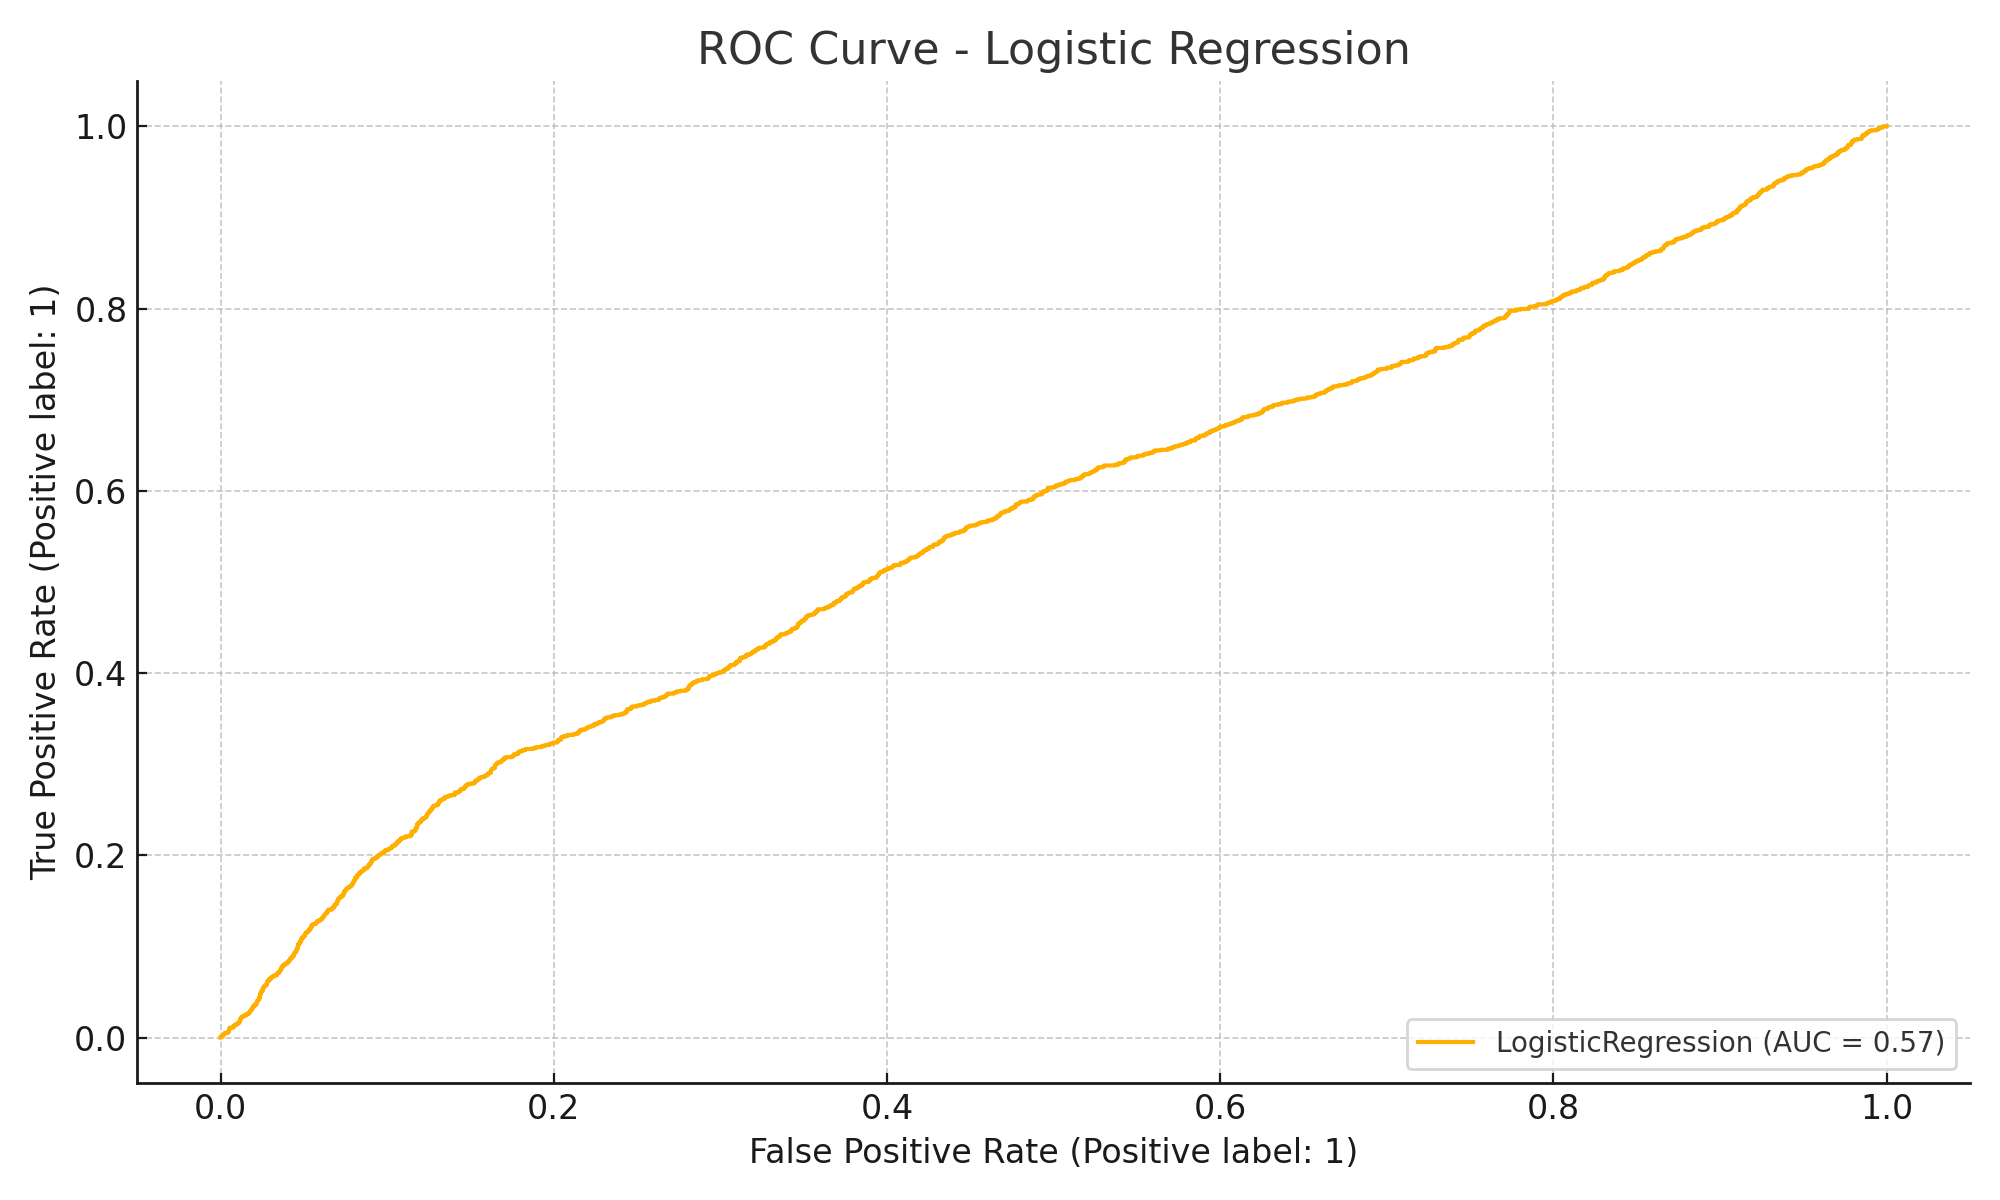

###  Output Summary:
```
              precision    recall  f1-score   support

           0       0.94      0.25      0.40     22039
           1       0.07      0.77      0.13      1566

    accuracy                           0.29     23605
   macro avg       0.50      0.51      0.26     23605
weighted avg       0.88      0.29      0.38     23605

Confusion Matrix:
[[ 5576 16463]
 [  363  1203]]

ROC AUC Score: 0.5672
```

## Random Forest

One of the models we chose was Random Forest. Random Forest models handle high dimensional data well as they do not require feature normalization or scaling. They also exhibit strong performance by aggregating the decisions of multiple decision trees, making them robust to overfitting and giving them the ability to capture complex relationships in the data. Random Forests can also be trained in parallel, which is important when working with a large dataset as we are in the project.

To train the Random Forest model, we used the first 80% of the data (chronologically ordered) as train/validation data. We used sklearn's TimeSeriesSplit (with 3 splits) in conjuction with a RandomizedSearchCV so that we could cross-validate the results of the data while searching over our hyperparameters and keeping the data chronologically ordered to prevent data leakage.

Initially, the best model was determined by scoring based on the ROC AUC. This resulted in a model with poor precision and recall scores when tested against validation data, so we switched to scoring the best model based on F1 score.

To train the model, data was first processed to convert the 'status_label' to a binary 0-1 feature. We also dropped the company name and year from the data, as these are not generalizable features for predicting future bankruptcy for an unseen company. Train and test data was then split up, and then the model was trained with a randomized search perfroming cross validation.

Since our dataset was unbalanced with the majority of entries belonging to non-bankrupt companies, we used a 'balanced' class weight feature as well as 'f1_macro' scoring so that our model would mitigate imbalance in the loss function and prioritize strong performance on both classes.

The hyperparameters searched over included the n_estimators, max_depth, min_samples_split, and min_samples_leaf. Additionally, we tested which threshold for our prediction output was best based on f1 score, and used this threshold when evaluating on the test set.

After training our model and observing the results, we saw that the most important features were Depreciation & Amortization to Sales, Capitalization to Earnings, and Long-term Debt to Capitalization. The least important features were all macro-economic indicators.

Overall the results are as follows:

**Best Training Metrics:**  
Threshold: 0.6  
Accuracy: 0.945  
Precision: 0.650  
Recall: 0.591  
F1 Score: 0.619  
ROC AUC: 0.948  

**Testing Metrics:**  
Accuracy: 0.949  
Precision: 0.205  
Recall: 0.303  
F1 Score: 0.245  
ROC AUC: 0.848

**Confusion Matrix:**  
[14811,   500],  
[  297,   129]  

**Confusion Matrix Normalized:**  
[0.967, 0.033],  
[0.697 , 0.303 ]  

Overall, the model performed very well when predicting the negative class (no bankruptcy), with 96.7% of negative class entries predicted correctly. However, the model struggled in predicting the positive class (bankruptcy), with just 30% of the positive class entries being correctly classified.

In [ ]:
ordered_data = data_clean.sort_values(by='year')    # preserves chronological ordering

In [ ]:
rf_data = ordered_data.drop(['company_name', 'year'], axis=1)

In [ ]:
# Alive = 0, Dead = 1
rf_data['status_label'] = rf_data['status_label'].map({'alive': 0, 'failed': 1})

In [ ]:
X = rf_data.drop('status_label', axis=1)
y = rf_data['status_label']

assert not X.isnull().any().any()
assert not y.isnull().any().any()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_importance(X, rnd_clf):
  importances_df = pd.DataFrame({
      'Feature': X.columns,
      'Importance': rnd_clf.feature_importances_
  }).sort_values(by='Importance', ascending=False)

  plt.figure(figsize=(10, 6))
  plt.barh(importances_df['Feature'], importances_df['Importance'], color='skyblue')
  plt.xlabel('Importance Score')
  plt.title('Feature Importances from Random Forest')
  plt.gca().invert_yaxis()
  plt.tight_layout()
  plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_metrics(y_test, y_pred, y_pred_proba, X_test):
  return accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0.0), recall_score(y_test, y_pred), f1_score(y_test, y_pred), roc_auc_score(y_test, y_pred_proba)

In [ ]:
train_idx = int(len(rf_data) * 0.8)
X_train = X[:train_idx]
X_test = X[train_idx:]
y_train = y[:train_idx]
y_test = y[train_idx:]

In [ ]:
# Training process that was run

# from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
# from sklearn.ensemble import RandomForestClassifier

# n_estimators_list = np.linspace(100, 500, 10).astype(int)
# max_depth_list = [8, 12, 16, 20, 24, None]
# min_samples_split_list = [2, 5, 10]
# min_samples_leaf_list = [1, 2, 4, 8, 12]
# max_features_list = ['sqrt']

# param_dist = {
#     'n_estimators': n_estimators_list,
#     'max_depth': max_depth_list,
#     'min_samples_split': min_samples_split_list,
#     'min_samples_leaf': min_samples_leaf_list,
#     'class_weight': ['balanced'],
#     'max_features': max_features_list
# }

# tscv = TimeSeriesSplit(n_splits=3)

# search = RandomizedSearchCV(RandomForestClassifier(random_state=42),
#                             param_distributions=param_dist,
#                             n_iter=30, cv=tscv, scoring='f1_macro', verbose=2)
# search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END class_weight=balanced, max_depth=24, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=322; total time=  26.2s
[CV] END class_weight=balanced, max_depth=24, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=322; total time=  57.6s
[CV] END class_weight=balanced, max_depth=24, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=322; total time= 1.6min
[CV] END class_weight=balanced, max_depth=16, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=277; total time=  21.3s
[CV] END class_weight=balanced, max_depth=16, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=277; total time=  46.2s
[CV] END class_weight=balanced, max_depth=16, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=277; total time= 1.3min
[CV] END class_weight=balanced, max_depth=8, max_features=sqrt, min_samples_leaf=

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=RandomForestClassifier(random_state=42), n_iter=30,
                   param_distributions={'class_weight': ['balanced'],
                                        'max_depth': [8, 12, 16, 20, 24, None],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2, 4, 8, 12],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': array([100, 144, 188, 233, 277, 322, 366, 411, 455, 500])},
                   scoring='f1_macro', verbose=2)

In [ ]:
print(search.best_params_)
print(search.best_score_)

{'n_estimators': np.int64(455), 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 12, 'class_weight': 'balanced'}
0.5734784883581351


In [ ]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(
    n_estimators=455,
    min_samples_split=2,
    min_samples_leaf=8,
    max_features='sqrt',
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Retraining best model on the entire dataset:
best_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=12, min_samples_split=5,
                       n_estimators=np.int64(188), random_state=42)

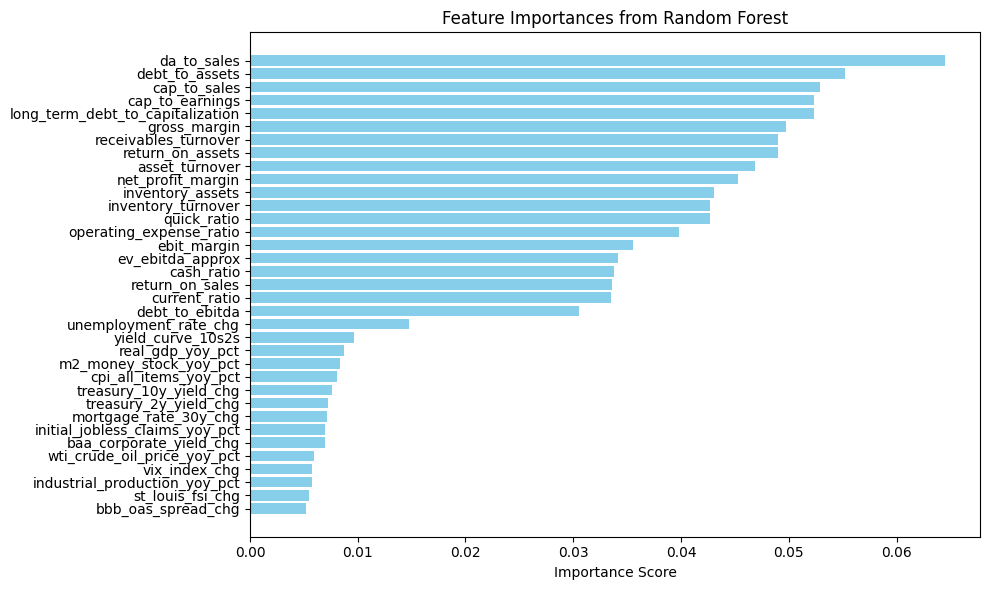

In [ ]:
plot_feature_importance(X, best_model)

In [ ]:
y_pred_proba = best_model.predict_proba(X_train)[:, 1]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

best_metrics = []
best_threshold = None
best_f1_score = 0

for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)

    accuracy, precision, recall, f1, roc_auc = get_metrics(y_train, y_pred, y_pred_proba, X_train)
    if f1 > best_f1_score:
      best_f1_score = f1
      best_threshold = threshold
      best_metrics = [accuracy, precision, recall, f1, roc_auc]

print('Best Training Metrics - based on F1 score:')
print(f'Threshold: {best_threshold}')
print(f'Accuracy: {best_metrics[0]}')
print(f'Precision: {best_metrics[1]}')
print(f'Recall: {best_metrics[2]}')
print(f'F1 Score: {best_metrics[3]}')
print(f'ROC AUC: {best_metrics[4]}')

Best Training Metrics - based on F1 score:
Threshold: 0.6
Accuracy: 0.9399157995075066
Precision: 0.61
Recall: 0.5853149770546516
F1 Score: 0.5974025974025974
ROC AUC: 0.9402150639323213


In [ ]:
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= best_threshold).astype(int)

accuracy, precision, recall, f1, roc_auc = get_metrics(y_test, y_pred, y_pred_proba, X_test)

print('Testing Metrics:')
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'ROC AUC: {roc_auc}')

Testing Metrics:
Accuracy: 0.944970451801487
Precision: 0.20350404312668463
Recall: 0.3544600938967136
F1 Score: 0.2585616438356164
ROC AUC: 0.8492568631040373


In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[14720,   591],
       [  275,   151]])

In [ ]:
confusion_matrix(y_test, y_pred, normalize='true')

array([[0.9614003 , 0.0385997 ],
       [0.64553991, 0.35446009]])

## Gradient Boost and XGBoost (Yevgen)

### Feature Engineering and Selection

We include both contemporaneous and one-year-lagged versions of every firm and macro variable. Lags allow the algorithms to pick up momentum and deterioration trends—e.g., a steep fall in ROA or a sudden rise in unemployment preceding distress. The trade-off is that the very first year any company appears must be discarded (lag values are NaN); overall sample size drops but the incremental predictive signal easily outweighs that loss. Additionally, because the scale of features does not affect tree based models, both ratios and original features are included.


In [ ]:
from sklearn.metrics import average_precision_score, make_scorer, precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [ ]:
def add_lagged_features(df, lag, columns):
    data_clean_offset = df[columns].copy()
    data_clean_offset['year'] = data_clean_offset['year'] + lag
    data_clean_offset = data_clean_offset.drop(columns=['status_label'])
    data_clean_offset.columns = data_clean_offset.columns + f'_lag_{lag}'
    data_clean_offset.rename(columns={f'year_lag_{lag}': 'year', f'company_name_lag_{lag}': 'company_name'}, inplace=True)
    df = df.merge(data_clean_offset, on=['company_name', 'year'], how='left')
    return df

# NOTE: use the raw values AND ratios
data_clean = df.sort_values('year').merge(macro_features, on='year', how='left')
cols = data_clean.columns
# NOTE: adding lagged features reduces the data set. a company that didn't existin year T-1 will have NaN values in lagged features.
data_clean = add_lagged_features(data_clean, 1, cols)
data_clean = data_clean.dropna()
print(data_clean.shape)
print(data_clean.columns)
print(data_clean.year.unique())

(68901, 109)
Index(['company_name', 'status_label', 'year', 'current_assets', 'cogs',
       'depreciation_amortization', 'ebitda', 'inventory', 'net_income',
       'total_receivables',
       ...
       'initial_jobless_claims_yoy_pct_lag_1', 'yield_curve_10s2s_lag_1',
       'treasury_10y_yield_chg_lag_1', 'treasury_2y_yield_chg_lag_1',
       'baa_corporate_yield_chg_lag_1', 'bbb_oas_spread_chg_lag_1',
       'mortgage_rate_30y_chg_lag_1', 'unemployment_rate_chg_lag_1',
       'st_louis_fsi_chg_lag_1', 'vix_index_chg_lag_1'],
      dtype='object', length=109)
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018]


### CV Fold Prep

To mimic a real investment or lending workflow we adopt a purely temporal split: every observation dated after our cut‐off year (≈ 20 % of the records) is withheld as the test set. This prevents “peek-ahead” bias—information from future economic regimes or post-event balance sheets can never leak backward into model training. A random split would overstate performance because many firms appear repeatedly over time and later-year patterns can be easier to classify once earlier labels are seen.

Additionally, we need to prepare the CV folds in a way that we do not leak future information into the validation set. For cross-validation, we use walk-forward split approach, which grows both the training and validation sets with each fold.

In [ ]:
def walk_forward_split(X: pd.DataFrame, n_folds: int, val_length: int):
    """
    Walk forward split for time series data

    Args:
        X (pd.DataFrame): Dataframe with time series data
        n_folds (int): Number of folds
        val_length (int): Length of validation set

    Returns:
        list: List of tuples of train and validation indices
    """
    years = X['year'].unique()
    val_years = np.reshape(years[(n_folds)*-val_length:], (n_folds, val_length))
    for i in range(n_folds):
        last_train_year = np.min(val_years[i])-1
        print(f'train end: {last_train_year}, val: {val_years[i]}')
        yield X[X.year <= last_train_year].index, X[(X.year.isin(val_years[i]))].index

TEST_YEAR_START = 2015
TARGET_COL = 'status_label'
y = data_clean[TARGET_COL].map({'alive': 0, 'failed': 1})
X = data_clean.drop(columns=[TARGET_COL])

train_mask = X.year < TEST_YEAR_START
X_train = X[train_mask].reset_index(drop=True)
y_train = y[train_mask].reset_index(drop=True)
X_test = X[~train_mask].reset_index(drop=True)
y_test = y[~train_mask].reset_index(drop=True)

cv_splits = list(walk_forward_split(X_train, n_folds=3, val_length=3))

train end: 2005, val: [2006 2007 2008]
train end: 2008, val: [2009 2010 2011]
train end: 2011, val: [2012 2013 2014]


### Model Training

Bankruptcy is a rare-event, non-linear classification problem. Gradient Boosting (GB) and XGBoost (XGB) are well suited because they create an ensemble of shallow decision trees that (a) capture complex interactions among dozens of accounting ratios, market-value measures and macro factors, and (b) deal gracefully with heterogeneous feature scales without extensive preprocessing. XGB adds second-order information and built-in L1/L2 regularisation, giving it an edge in both speed and over-fit control when the feature set is partly collinear.

#### Scoring Algorithm Selection
Because bankruptcies account for only a few percent of rows, accuracy and even ROC-AUC can be misleading. We therefore optimise PR-AUC (average precision), which focuses on ranking the minority “default” class. PR-AUC rises only when the model simultaneously improves recall (fewer missed defaults) and precision (fewer false alarms)—exactly the business objective.

In [ ]:
pr_auc = make_scorer(average_precision_score, response_method="predict_proba")

#### Gradient Boost

In [ ]:
gb_params = {
    'clf__n_estimators': [800],
    'clf__learning_rate': [0.05],
    'clf__max_depth': [7],
    'clf__min_samples_split': [10],
    'clf__min_samples_leaf': [10],
    'clf__subsample': [0.7],
    'clf__max_features': ['sqrt'],
    'clf__ccp_alpha': [0],
}

gb = GradientBoostingClassifier(
    random_state=0,
)

pipe = Pipeline([("clf", gb)])


grid = GridSearchCV(
    estimator=pipe,
    param_grid=gb_params,
    scoring=pr_auc,
    cv=cv_splits,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

class_freq = y_train.value_counts(normalize=True)
row_weights = y_train.map(lambda t: 1.0 / class_freq[t]).values

fit_kwargs = {"clf__sample_weight": row_weights}
grid.fit(X_train.drop(columns=['company_name', 'year']), y_train, **fit_kwargs)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


GridSearchCV(cv=[(Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       26179, 26180, 26181, 26182, 26183, 26184, 26185, 26186, 26187, 26188],
      dtype='int64', length=26189),
                  Index([26189, 26190, 26191, 26192, 26193, 26194, 26195, 26196, 26197, 26198,
       ...
       37429, 37430, 37431, 37432, 37433, 37434, 37435, 37436, 37437, 37438],
      dtype='int64', length=11250)),
                 (Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       37429, 37430, 37431, 3743...
                                        GradientBoostingClassifier(random_state=0))]),
             n_jobs=-1,
             param_grid={'clf__ccp_alpha': [0], 'clf__learning_rate': [0.05],
                         'clf__max_depth': [7], 'clf__max_features': ['sqrt'],
                         'clf__min_samples_leaf': [10],
                         'clf__min_samples_split': [10],
                         'clf__n_estimators': [800], 'clf__subsample': [0.7]},
             scoring=make_scorer(average_precision_score, response_method='predict_proba'),
             verbose=1)

In [ ]:
feat_importances = pd.Series(index=grid.feature_names_in_, data=grid.best_estimator_.named_steps['clf'].feature_importances_).sort_values(ascending=False)
res = pd.DataFrame(grid.cv_results_)
res.T

,0
mean_fit_time,380.776175
std_fit_time,60.386934
mean_score_time,0.816545
std_score_time,0.400778
param_clf__ccp_alpha,0
param_clf__learning_rate,0.05
param_clf__max_depth,7
param_clf__max_features,sqrt
param_clf__min_samples_leaf,10
param_clf__min_samples_split,10


#### XGBoost

In [ ]:
# scale_pos_weight ≈ #neg / #pos
spw = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
        tree_method="hist",
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=0,
        scale_pos_weight=spw,
        n_jobs=-1,

)

steps_xgb = [("xgb", xgb)]
pipe_xgb = Pipeline(steps_xgb)

param_grid_xgb = {
    "xgb__max_depth": [9],
    "xgb__reg_alpha": [10],
    "xgb__reg_lambda": [1],
    "xgb__subsample": [0.7],
    "xgb__colsample_bytree": [0.7],
    "xgb__learning_rate": [0.05],
    "xgb__n_estimators": [1000],
    "xgb__min_child_weight": [3],
    "xgb__gamma": [0.2],
}
grid_xgb = GridSearchCV(
    pipe_xgb,
    param_grid_xgb,
    cv=cv_splits,
    scoring=pr_auc,
    n_jobs=-1,
    refit=True,
    verbose=1)

grid_xgb.fit(X_train.drop(columns=['company_name', 'year']), y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


GridSearchCV(cv=[(Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       26179, 26180, 26181, 26182, 26183, 26184, 26185, 26186, 26187, 26188],
      dtype='int64', length=26189),
                  Index([26189, 26190, 26191, 26192, 26193, 26194, 26195, 26196, 26197, 26198,
       ...
       37429, 37430, 37431, 37432, 37433, 37434, 37435, 37436, 37437, 37438],
      dtype='int64', length=11250)),
                 (Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       37429, 37430, 37431, 3743...
                                                      random_state=0, ...))]),
             n_jobs=-1,
             param_grid={'xgb__colsample_bytree': [0.7], 'xgb__gamma': [0.2],
                         'xgb__learning_rate': [0.05], 'xgb__max_depth': [9],
                         'xgb__min_child_weight': [3],
                         'xgb__n_estimators': [1000], 'xgb__reg_alpha': [10],
                         'xgb__reg_lambda': [1], 'xgb__subsample': [0.7]},
             scoring=make_scorer(average_precision_score, response_method='predict_proba'),
             verbose=1)

In [ ]:
feat_importances_xgb = pd.Series(index=grid_xgb.feature_names_in_, data=grid_xgb.best_estimator_.named_steps['xgb'].feature_importances_).sort_values(ascending=False)
res = pd.DataFrame(grid_xgb.cv_results_)
res.T

,0
mean_fit_time,100.861895
std_fit_time,13.083746
mean_score_time,1.083069
std_score_time,0.45836
param_xgb__colsample_bytree,0.7
param_xgb__gamma,0.2
param_xgb__learning_rate,0.05
param_xgb__max_depth,9
param_xgb__min_child_weight,3
param_xgb__n_estimators,1000


#### Feature Importance
The rank correlation of feature importances between the two models is modest. After reviewing the feature importances, it is clear that the two models are using different features to make predictions. XBG is likely better able to capture non-linear relationships between features and the target variable.

In [ ]:
all_feat = feat_importances_xgb.rename('XGB').to_frame().join(feat_importances.rename('GB'))
all_feat.corr('spearman')

,XGB,GB
XGB,1.000000,0.625402
GB,0.625402,1.000000


### Model Tuning
I ran a series of grid searches to tune the parameters below. In an effort to reduce training time, I ran series of grid searches with subsets of features to avoid cartesian product explosion.

| Model   | Parameter                                | Why it matters                           | Intuition behind best value                                          | Range tested |
| ------- | ---------------------------------------- | ---------------------------------------- | -------------------------------------------------------------------- | ------------ |
| **GB**  | `n_estimators`                           | More trees increase model capacity       | 800 trees compensate for the small 0.01 learning rate.               | 200 - 1000   |
|         | `learning_rate`                          | Shrinkage controls step size             | 0.05 suppresses over-fit when many trees are built.                  | 0.001 - 0.01 |
|         | `max_depth`                              | Limits tree interaction order            | 5 lets GB model non-linear ratios while staying shallow.             | 3 - 9        |
|         | `min_samples_split` & `min_samples_leaf` | Prevent splits on tiny, noisy sub-groups | Setting both to 10 prunes spurious patterns in thin bankruptcy data. | 1 - 10       |
|         | `subsample`                              | Row-level bagging                        | 0.7 injects randomness and reduces variance.                         | 0.5 - 0.9    |
|         | `max_features`                           | Column-level bagging                     | `None` Allows for all festures to be used                            | sqrt, log2   |
|         | `ccp_alpha`                              | Cost-complexity post-prune               | 0 because earlier depth/leaf limits already regularise.              | 0.01 - 10    |
| **XGB** | `n_estimators`                           | Number of boosting rounds                | 1000 rounds pair with a modest 0.05 learning rate.                   | 100 - 2000   |
|         | `max_depth`                              | Tree complexity                          | 9 is deeper than GB but other penalties rein it in.                  | 3 - 15       |
|         | `learning_rate`                          | Shrinkage                                | 0.05 balances convergence speed and generalisation.                  | 0.01 - 0.1   |
|         | `reg_alpha` (L1)                         | Drives leaf weights to zero              | 10 forces sparsity—helpful with correlated features.                 | 0 - 10       |
|         | `reg_lambda` (L2)                        | Smooths remaining weights                | 1 adds mild ridge-style stabilisation.                               | 0 - 100      |
|         | `gamma`                                  | Min loss reduction to split              | 0.2 prevents frivolous deep splits.                                  | 0 -2         |
|         | `subsample`, `colsample_bytree`          | Row/feature bagging                      | 0.8/0.8 further decorrelate deep trees.                              | 0.5 - 1      |
|         | `min_child_weight`                       | Minimum Hessian weight in a leaf         | 3 blocks splits on very rare cases, curbing over-fit.                | 1 - 5        |


I selected most relevant parameters to tune for both algorithms. There was a mixture of model complexity and overfitting control/regularization. One interesting note, I tried aggressively regularizing the model as `max_depth` parameter was seemingly improving the model performance during validation. However, it led to overfitting on the test set and worse performance.

### Prediction

In [ ]:
y_pred_gb = grid.best_estimator_.predict_proba(X_test.drop(columns=['company_name','year']))
y_pred_xgb = grid_xgb.best_estimator_.predict_proba(X_test.drop(columns=['company_name','year']))

### Model Evaluation

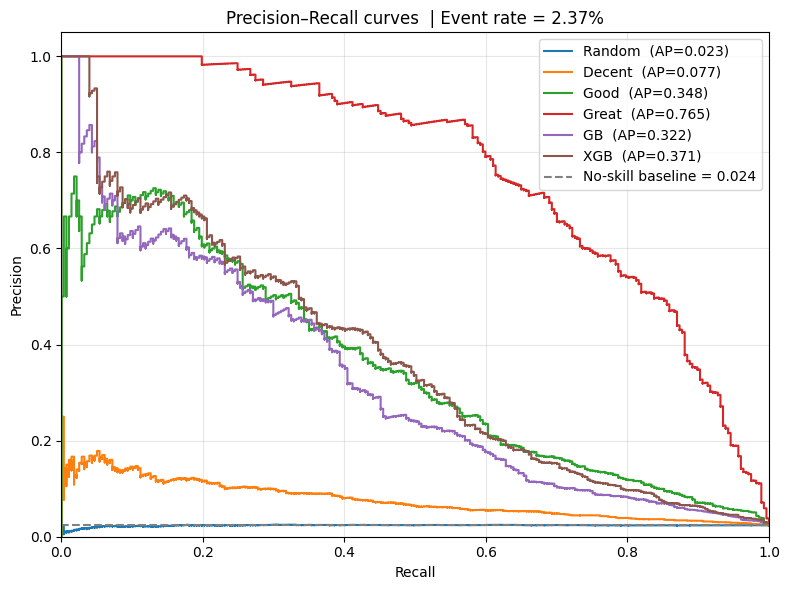

In [ ]:
event_rate = y_test.sum() / y_test.shape[0]
n_samples = y_test.shape[0]
seed = 0

# Generate ground-truth labels
rng = np.random.default_rng(seed)
y_true_noise = np.zeros(n_samples, dtype=int)
y_true_noise[: int(event_rate * n_samples)] = 1          # positives first
rng.shuffle(y_true_noise)                              # shuffle rows

# Simulate classifier scores
#     (larger 'shift' → stronger separation → higher PR-AUC)
def make_scores(labels, shift):
    """Return score array with given positive class shift."""
    noise = rng.normal(0, 1, labels.size)
    return noise + shift * labels

score_random = rng.random(n_samples)             # random ∈ [0,1]
score_decent = make_scores(y_true_noise, shift=1.0)    # ≈ 5× baseline
score_good   = make_scores(y_true_noise, shift=2.0)    # ≈ 10× baseline
score_great  = make_scores(y_true_noise, shift=3.0)    # ≈ 15× baseline

models = {
    "Random": [score_random, y_true_noise],
    "Decent": [score_decent, y_true_noise],
    "Good": [score_good, y_true_noise],
    "Great": [score_great, y_true_noise],
    "GB": [y_pred_gb[:, 1], y_test],
    "XGB": [y_pred_xgb[:, 1], y_test],
}

# Plot precision-recall curves & print PR-AUC values
plt.figure(figsize=(8, 6))
for name, scores in models.items():
    precision, recall, _ = precision_recall_curve(scores[1], scores[0])
    ap = average_precision_score(scores[1], scores[0])
    plt.step(recall, precision, where="post", label=f"{name}  (AP={ap:.3f})")

# Reference line = prevalence (no-skill)
baseline = event_rate
plt.hlines(baseline, 0, 1, colors="grey", linestyles="--",
           label=f"No-skill baseline = {baseline:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall curves  | Event rate = {event_rate:.2%}")
plt.ylim(0, 1.05)
plt.xlim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The chart above compares precision-recall curves that represent successively stronger classifiers against the **no-skill baseline**. Here’s what the set-up illustrates and why it is useful for evaluating this model.

**1  Baseline anchored to event rate**
In a precision-recall (PR) plot the horizontal dashed line at *precision = p* is the performance of a random, uninformative classifier; *p* equals the prevalence of the positive class.  Plotting that line reminds the audience that PR-AUC is **scale-dependent**: if only 1 % of firms default, the area under a random PR curve is \~0.01.  A model that lifts PR-AUC to 0.10 is therefore delivering a ten-fold improvement even though 0.10 might look small in absolute terms.

**2  Visualising “decent / good / great” lifts**
The simulated *Decent*, *Good* and *Great* curves shift the score distribution of bankrupt firms by 1, 2 and 3 standard deviations, roughly producing 5×, 10× and 15× the baseline PR-AUC.  Drawing all four curves together makes the notion of “decent” or “good” intuitive: the tighter the band between the curve and the no-skill line, the less economic value the model adds; the more the curve bulges toward the top-right, the more accurately the model ranks true defaults ahead of healthy firms.

**3  Threshold-free and cost-aware**
Because PR-AUC integrates precision and recall over every possible cut-off, it avoids the need to pick a decision threshold during model-selection. At the same time, the y-axis (precision) links directly to the **cost of false alarms** while the x-axis (recall) ties to **missed-default cost**. Stakeholders can therefore decide, after viewing the curves, where to operate—for example, choose the point at 95 % recall if Type II error is deemed catastrophic even at the expense of precision.

#### Threshold Selection
When a bankruptcy-prediction model outputs a probability (e.g., “there is a 32 % chance this firm will default in the next year”), the analyst must convert that continuous score into a binary decision by choosing a threshold.  The choice is neve neutral: it determines how often we raise a red flag (positives) versus how often we let a firm pass (negatives) and therefore governs the balance between Type I errors (false alarms on healthy firms) and Type II errors (missed bankruptcies).

In credit-risk and investment settings a missed default is usually far more expensive than a false alarm.  Suppose we set a very low threshold such as 5 %.  Nearly every firm with even a modest hint of distress will be tagged “at risk,” recall will approach 100 % and Type II error will collapse—but precision will tumble and analysts will drown in investigations, relationship officers will see good clients rejected, and portfolio turnover will spike (high Type I cost).  Conversely, a high threshold such as 40 % makes the model issue warnings only when it is very confident.  Precision rises and workflow noise drops, yet recall falls and the bank may be blindsided by defaults it failed to pre-empt (Type II cost).  The ideal threshold therefore sits where the marginal benefit of catching one more bankruptcy is equal to, or just exceeds, the marginal cost of one more false alarm.

Macroeconomic regimes shift, portfolios change and models degrade: a cut-off calibrated on 2015-2018 defaults may be too lenient in a recessionary spike or too stringent in an expansion.  Monitoring the realised Type I and Type II rates every quarter and re-tuning the threshold (while holding the model fixed) is therefore routine governance.  In short, the threshold is not a property of the algorithm—it is a business decision layer that should be adjusted to align model behaviour with the evolving risk appetite and economic cost structure.

Some approaches to setting the bound include:
- Cost-based optimization: Build a simple loss matrix—\$1 of cost for a false-positive investigation, \$1000 for a false-negative charge-off—and pick the threshold that minimises expected cost on the validation set.
- Recall floor with precision maximization: dictate a minimum sensitivity (e.g., ≥ 95 % of historical defaults must be flagged). Among all thresholds that satisfy that floor, choose the one that yields the highest precision (or lowest false-positive rate).

A reasonable approach - maximizing F1 is also shown below for choosing the threshold.

In [ ]:
gb_res = pd.DataFrame()
for algo, y_pred_algo in zip(['GB', 'XGBoost'], [y_pred_gb, y_pred_xgb]):
  best_f1 = 0
  for thresh in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_proba = y_pred_algo[:, -1]
    y_pred_label = (y_pred_proba >= thresh).astype(int)

    accuracy, precision, recall, f1, roc_auc = get_metrics(y_test, y_pred_label, y_pred_proba, X_test)
    ap = average_precision_score(y_test, y_pred_label)
    if f1 > best_f1:
      best_f1 = f1
      gb_res.loc['best threshold', algo] = thresh
      gb_res.loc['accuracy', algo] = accuracy
      gb_res.loc['precision', algo] = precision
      gb_res.loc['recall', algo] = recall
      gb_res.loc['f1', algo] = f1
      gb_res.loc['roc_auc', algo] = roc_auc
      gb_res.loc['average_precision', algo] = ap

gb_res

,GB,XGBoost
best threshold,0.700000,0.600000
accuracy,0.971754,0.968758
precision,0.399240,0.371345
recall,0.379061,0.458484
f1,0.388889,0.410339
roc_auc,0.876953,0.896019
average_precision,0.166059,0.183095


## Neural Network (Gabrielle)

For my algorithm, I chose to implement a neural network. I started by splitting the data into training, validation, and testing sets, designing a random search to find the best hyperparameters, and then analyzing the results and comparing them to a basic model.

### Splitting data into Training and Testing

To begin, I split my data into training, validation, and testing sets. Since the dataset is based on yearly data, I split the data by year to ensure that validation and testing years are later than the training data, avoiding overlap that could introduce potential model bias. I chose to have the largest set of dates for training and split the rest for testing and validation.

### Designing a Random Search

I designed a random search model to find the best hyperparameters for my set. I initially ran the search without regularization, balanced class weights, or early stopping. In addition, I used accuracy as a performance measure, which showed high results, but this was a direct result of the imbalance between the classes. The hyperparameters and their value ranges are listed below, as well as the best hyperparameters found.

#### Hyperparamter Ranges
* Hidden layers: 1 - 4
* Number of neurons: 16 - 208
* Learning rate: 1e-4 - 1e-3
* Activations: "relu", "swish", and "elu"
* Regularization: "dropout", "l2", and None
* Optimizer: "sgd", "adam", abd "rmsprop"

#### Best Hyperparamteters Found
* Hidden layers: 3
* Number of neurons: 112
* Learning rate: 0.000975189963465304
* Activations: "relu"
* Regularization: None
* Optimizer: "adam"

Due to the disproportion between the "failed" and "alive" status labels, I introduced weight balancing to address the bias in the dataset and minimize skewed results. This causes the model to oversample the underrepresented "failed" minority class to better train to recognize failed cases. I also changed to AUC as a performance measure since it is a more accurate metric for this type of model and does not misrepresent performance as a result of biased data. In addition, to limit runtime of the random search, I added early stopping to eliminate search trials in which the validation AUC was not improving at an acceptable rate. Lastly, I added a regularization parameter to prevent overfitting of my model.

### Comparing to a Basic Model

I wanted to compare the accuracy of my model to a very basic neural network with only two layers. The basic model achieved an AUC of around 80%. After finalizing my hyperparameters, I was able to achieve an AUC of around 70%, showing that my model does not perform better than a basic model. I believe that part of the contributing factors to higher performance in the basic model is that it does not implement weight balancing, so the model is biased based on the unequal representation of classes.

### Confusion Matrix and Learning Curves

While I was able to increase my testing accuracy, however, when I plotted the confusion matrix I realized that my model was hardly correctly predicting the "failed" status and was primarily predicting them as "alive" status labels, which can result in  misleading performance due to the disproportionately high number os "alive" companies in the data. In future projects, i would change the status_ label to show failed for a duration of a companies active period as opposed to just for the final year. I believe that this would imporve the way the model processed "failed" and "alive" status labels, as well as reduce the bias and disproportionality in status labels. This shows that even with the weight balancing for the classes, the set is still not generalized enough to the minority class, and continues to predict the majority class disproportionately.

The Learning curve for the final model show that Training loss and AUC are steadily increasing which indicates that the model is learning well at a maintained rate. The validation loss and AUC however are eratic and unpredictable and do not follow a linear model, unlike the training curves.

### Final Model

My final model does achieve a fairly high AUC percentage and the learning curves show that it does not generalize well to new data. There are many issues with this data set that cause my model to have poor performance. The primary error is the underrepresentation of the minority class. Even with the implementation of weight balancing, the final model hardly performs better than athe basic model. Overall, based on my highest achievable AUC scores, I would not use this algorithm for predictions in relation to this data set.

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.7068 - f1_score: 0.9756 - loss: 0.3703 - precision: 0.9904 - recall: 0.8902
Test AUC: 0.7087
Test Precision: 0.9900
Test Recall: 0.8887
Test F1: 0.9749


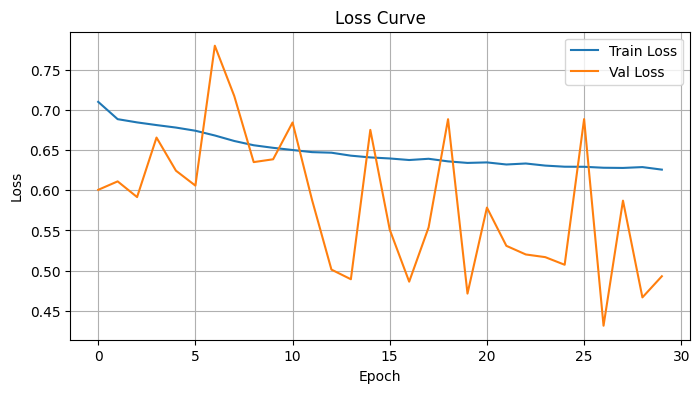

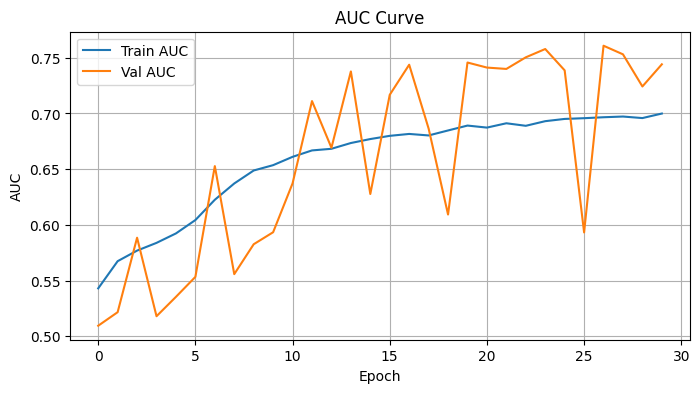

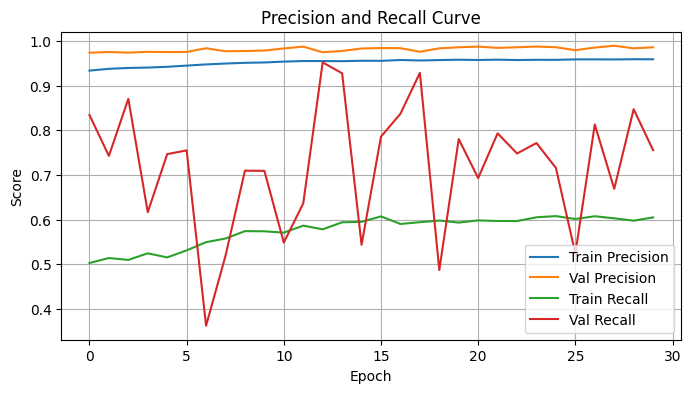

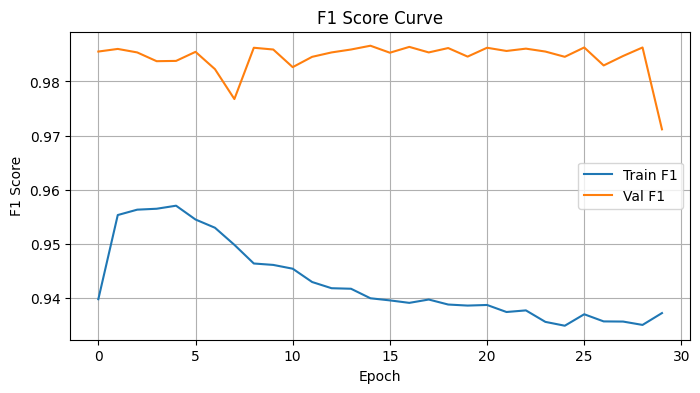

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Split the data into train, validation, and test sets
data_clean_sorted = data_clean.sort_values('year')

# Decide your year splits (example: train < 2015, valid 2015-2017, test > 2017)
train_years = range( data_clean_sorted['year'].min(), 2015 )
valid_years = range(2015, 2018)
test_years  = range(2018, data_clean_sorted['year'].max() + 1)

# Create boolean masks
train_mask = data_clean_sorted['year'].isin(train_years)
valid_mask = data_clean_sorted['year'].isin(valid_years)
test_mask  = data_clean_sorted['year'].isin(test_years)

# Extract features and labels
X = data_clean_sorted.drop(columns=['status_label'])
X.drop(columns=['company_name'], inplace=True)
y = data_clean_sorted['status_label'].map({'failed': 0, 'alive': 1})

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply masks to get splits
X_train = X_scaled[train_mask]
y_train = y[train_mask]
X_valid = X_scaled[valid_mask]
y_valid = y[valid_mask]
X_test  = X_scaled[test_mask]
y_test  = y[test_mask]

# Best hyperparameter values
n_hidden = 3
n_neurons = 112
learning_rate =  0.000975189963465304
activation  = "relu"
regularization = None
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

# Creation of model architecture with best hyperparameters
best_model = keras.Sequential()
for _ in range(n_hidden):
    best_model.add(keras.layers.Dense(n_neurons, activation=activation, kernel_initializer="he_normal"))
    best_model.add(keras.layers.BatchNormalization())
best_model.add(keras.layers.Dense(1, activation="sigmoid", kernel_initializer="he_normal"))

best_model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.F1Score(name="f1_score", threshold=0.3)
    ])

# Implementation of class weights to avoid bias towards the majority class
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw))

history = best_model.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_valid, y_valid),
    verbose=0,
    class_weight=class_weight_dict)

# Evaluate on test set
results = best_model.evaluate(X_test, y_test)
print(f"Test AUC: {results[1]:.4f}")
print(f"Test Precision: {results[2]:.4f}")
print(f"Test Recall: {results[3]:.4f}")
print(f"Test F1: {results[4]:.4f}")

# Plot learning curve
history_df = pd.DataFrame(history.history)

# Plot loss
plt.figure(figsize=(8, 4))
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot AUC
plt.figure(figsize=(8, 4))
plt.plot(history_df['auc'], label='Train AUC')
plt.plot(history_df['val_auc'], label='Val AUC')
plt.title('AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()

# Plot Precision and Recall
plt.figure(figsize=(8, 4))
plt.plot(history_df['precision'], label='Train Precision')
plt.plot(history_df['val_precision'], label='Val Precision')
plt.plot(history_df['recall'], label='Train Recall')
plt.plot(history_df['val_recall'], label='Val Recall')
plt.title('Precision and Recall Curve')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# Plot F1 scores for training and validation
plt.figure(figsize=(8, 4))
plt.plot(history_df['f1_score'], label='Train F1')
plt.plot(history_df['val_f1_score'], label='Val F1')
plt.title('F1 Score Curve')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()

# Results and Analysis

### Algroithm Performance Metrics
* KNN:
  * AUC: 0.5353
  * F1: 0.0152
  * Precision: 0.0400
  * Recall: 0.0093
* Random Forest:
  * AUC: 0.848
  * F1: 0.245
  * Precision: 0.205
  * Recall: 0.303
* Gradient Boost:
  * AUC: 0.876953
  * F1: 0.388889
  * Precision: 0.399240
  * Recall: 0.379061
* XGBoost:
  * AUC: 0.896019
  * F1: 0.410339
  * Precision: 0.371345
  * Recall:	0.458484
* Logistic Regression
  * AUC:0.5672
  * F1:0.291
  * Precision:0.071
  * Recall:0.771
* Neural Network
  * AUC: 0.7087
  * F1: 0.9749
  * Precision: 0.9900
  * Recall: 0.8887


## Analysis

To evaluate the effectiveness of different classification algorithms on the bankruptcy prediction task, we compared five models: K-Nearest Neighbors (KNN), Random Forest, Gradient Boosting/XGBoost, Logistic Regression, and a Neural Network. The primary metrics considered were AUC (Area Under the ROC Curve), F1 score, Precision, and Recall.

### K-Nearest Neighbors (KNN)
The KNN algorithm performed poorly across all metrics, with an AUC of 0.5353, F1 score of 0.0152, Precision of 0.0400, and Recall of 0.0093. These results indicate that KNN struggled to distinguish between the classes and was unable to effectively identify failed companies. The very low F1 and Recall suggest that the model rarely predicted the minority class, likely due to class imbalance and the limitations of KNN with high-dimensional or imbalanced data.

### Random Forest
Random Forest achieved the highest AUC of 0.848 among the tested models, indicating strong overall discrimination between classes. Its F1 score (0.245), Precision (0.205), and Recall (0.303) were also the best among the non-neural models, though still relatively low. This suggests that while Random Forest is effective at ranking companies by risk, it still struggles to balance false positives and false negatives, likely due to the unbalanced representation of the dataset.

### Gradient Boosting
The Gradient Boosting model achieved an AUC of 0.877, indicating strong ability to distinguish between failed and non-failed companies. Its F1 score of 0.389, precision of 0.399, and recall of 0.379 show a balanced performance in identifying the minority class. The relatively close values of precision and recall suggest that the model is not overly biased toward either false positives or false negatives, making it a reliable choice for this classification task.

### XGBoost
XGBoost outperformed Gradient Boosting in all metrics, with an AUC of 0.896, the highest among the models tested. Its F1 score of 0.410 and recall of 0.458 indicate that it is more effective at correctly identifying failed companies compared to Gradient Boosting. The precision of 0.371 is slightly lower than that of Gradient Boosting, suggesting a small increase in false positives, but this is offset by the improved recall. Overall, XGBoost provides the best balance between identifying true positives and minimizing false negatives, making it the top performer for this dataset.

### Neural Network
The Neural Network achieved an AUC of 0.7087, which is lower than Random Forest but higher than KNN. However, its F1 score (0.9749), Precision (0.9900), and Recall (0.8887) are relatively high. This suggests that the neural network is predicting almost all samples as the majority class ("alive"), resulting in high precision and recall for that class but not necessarily indicating good minority class detection. The discrepancy between AUC and F1/Recall/Precision highlights the importance of considering class imbalance and the need to interpret metrics carefully.


# Conclusion

Among the models tested for bankruptcy prediction, XGBoost demonstrated the best overall performance, achieving the highest AUC and a strong balance between precision and recall. Gradient Boosting and Random Forest also performed well, with good discrimination ability but slightly lower recall. Logistic Regression and KNN struggled to effectively identify failed companies, with low AUC and recall values. The Neural Network showed high precision and recall, but this was likely due to predicting the majority class, as indicated by its lower AUC. Overall, ensemble methods like XGBoost and Gradient Boosting are the most reliable choices for this imbalanced classification task, while simpler models and KNN are less effective.